# Customer 360 — Exploratory Data Analysis

This notebook explores the Customer 360 dataset to understand its structure, data quality, customer characteristics, churn distribution, and relationships between customer attributes and churn. The findings will guide the preprocessing and machine learning stages of the project.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Dataset/customer_360_ml_workshop.csv")

### Data Understanding

In [3]:
df.shape

(3000, 16)

In [4]:
df.head()

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,0,Yes,Yes,5.0,6287.08,Yes
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,1,No,Yes,4.0,4619.91,No
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,1,Yes,Yes,5.0,4512.25,No
3,CUST-00004,41,Giza,12,Month-to-month,DSL,312.5,420.40,3,2,1,No,Yes,5.0,3809.65,No
4,CUST-00005,40,Delta,21,Month-to-month,4G/5G,191.6,462.73,3,4,0,No,Yes,3.0,4731.09,No


In [5]:
df.tail()

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
2995,CUST-02996,51,Giza,14,One year,4G/5G,257.8,530.46,4,2,2,Yes,Yes,2.0,6353.49,No
2996,CUST-02997,33,Giza,36,Two year,Fiber,158.8,438.19,2,4,0,Yes,Yes,4.0,5956.22,No
2997,CUST-02998,36,Giza,20,Month-to-month,DSL,351.5,569.98,5,3,0,Yes,Yes,4.0,6233.85,No
2998,CUST-02999,41,Delta,4,One year,DSL,130.4,459.19,5,1,0,Yes,Yes,4.0,5590.18,Yes
2999,CUST-03000,53,Delta,1,Month-to-month,Fiber,269.5,379.02,2,2,1,No,Yes,4.0,2777.75,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           3000 non-null   str    
 1   Age                  3000 non-null   int64  
 2   Region               3000 non-null   str    
 3   TenureMonths         3000 non-null   int64  
 4   ContractType         3000 non-null   str    
 5   InternetType         2955 non-null   str    
 6   MonthlyUsageGB       2925 non-null   float64
 7   MonthlyChargeEGP     3000 non-null   float64
 8   NumServices          3000 non-null   int64  
 9   SupportCalls6M       3000 non-null   int64  
 10  LatePayments12M      3000 non-null   int64  
 11  PaperlessBilling     3000 non-null   str    
 12  AutoPay              3000 non-null   str    
 13  SatisfactionScore    2940 non-null   float64
 14  Future12MRevenueEGP  3000 non-null   float64
 15  Churn                3000 non-null   str    
dtyp

In [7]:
df.describe()

,Age,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Future12MRevenueEGP
count,3000.000000,3000.000000,2925.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000
mean,44.057667,25.540667,230.132855,487.345707,3.515000,2.206333,1.111000,3.486054,5361.156050
std,15.346319,16.525739,89.357331,118.451753,1.714085,1.503722,1.066016,1.013758,1479.868751
min,18.000000,1.000000,10.000000,142.400000,1.000000,0.000000,0.000000,1.000000,1529.370000
25%,31.000000,13.000000,169.500000,398.992500,2.000000,1.000000,0.000000,3.000000,4330.792500
50%,44.000000,22.000000,228.700000,484.995000,4.000000,2.000000,1.000000,4.000000,5274.620000
75%,57.000000,35.000000,290.400000,574.572500,5.000000,3.000000,2.000000,4.000000,6314.497500
max,70.000000,72.000000,597.900000,866.990000,6.000000,9.000000,6.000000,5.000000,11095.190000


In [8]:
df.describe(include='str')

,CustomerID,Region,ContractType,InternetType,PaperlessBilling,AutoPay,Churn
count,3000,3000,3000,2955,3000,3000,3000
unique,3000,5,3,3,2,2,2
top,CUST-00001,Cairo,Month-to-month,Fiber,Yes,Yes,No
freq,1,983,1680,1350,2110,1684,2456


In [9]:
def check_dataframe(data):
    percentage = data.isnull().sum() / data.shape[0] * 100
    return pd.DataFrame({
        "Data Type": data.dtypes,
        "Unique Values": data.nunique(),
        "Null Values": data.isnull().sum(),
        "Null Values Percentage": percentage.round(2)
    })

check_dataframe(df)

,Data Type,Unique Values,Null Values,Null Values Percentage
CustomerID,str,3000,0,0.0
Age,int64,53,0,0.0
Region,str,5,0,0.0
TenureMonths,int64,72,0,0.0
ContractType,str,3,0,0.0
InternetType,str,3,45,1.5
MonthlyUsageGB,float64,1920,75,2.5
MonthlyChargeEGP,float64,2893,0,0.0
NumServices,int64,6,0,0.0
SupportCalls6M,int64,10,0,0.0


In [10]:
df.duplicated().sum()

np.int64(0)

### Churn Distribution and Business Patterns

In [11]:
churn_counts = df["Churn"].value_counts()
churn_rates = df["Churn"].value_counts(normalize=True).mul(100).round(2)

print("Churn percentages:")
churn_rates.to_frame("Percentage")

Churn percentages:


,Percentage
Churn,
No,81.87
Yes,18.13


In [12]:
contract_churn = pd.crosstab(df["ContractType"], df["Churn"], normalize="index").mul(100).round(2)

autopay_churn = pd.crosstab(df["AutoPay"], df["Churn"], normalize="index").mul(100).round(2)

print("Churn rate by contract type (%):")
display(contract_churn)

print("Churn rate by AutoPay (%):")
display(autopay_churn)

Churn rate by contract type (%):


Churn,No,Yes
ContractType,,
Month-to-month,73.39,26.61
One year,91.28,8.72
Two year,94.86,5.14


Churn rate by AutoPay (%):


Churn,No,Yes
AutoPay,,
No,76.60,23.40
Yes,85.99,14.01


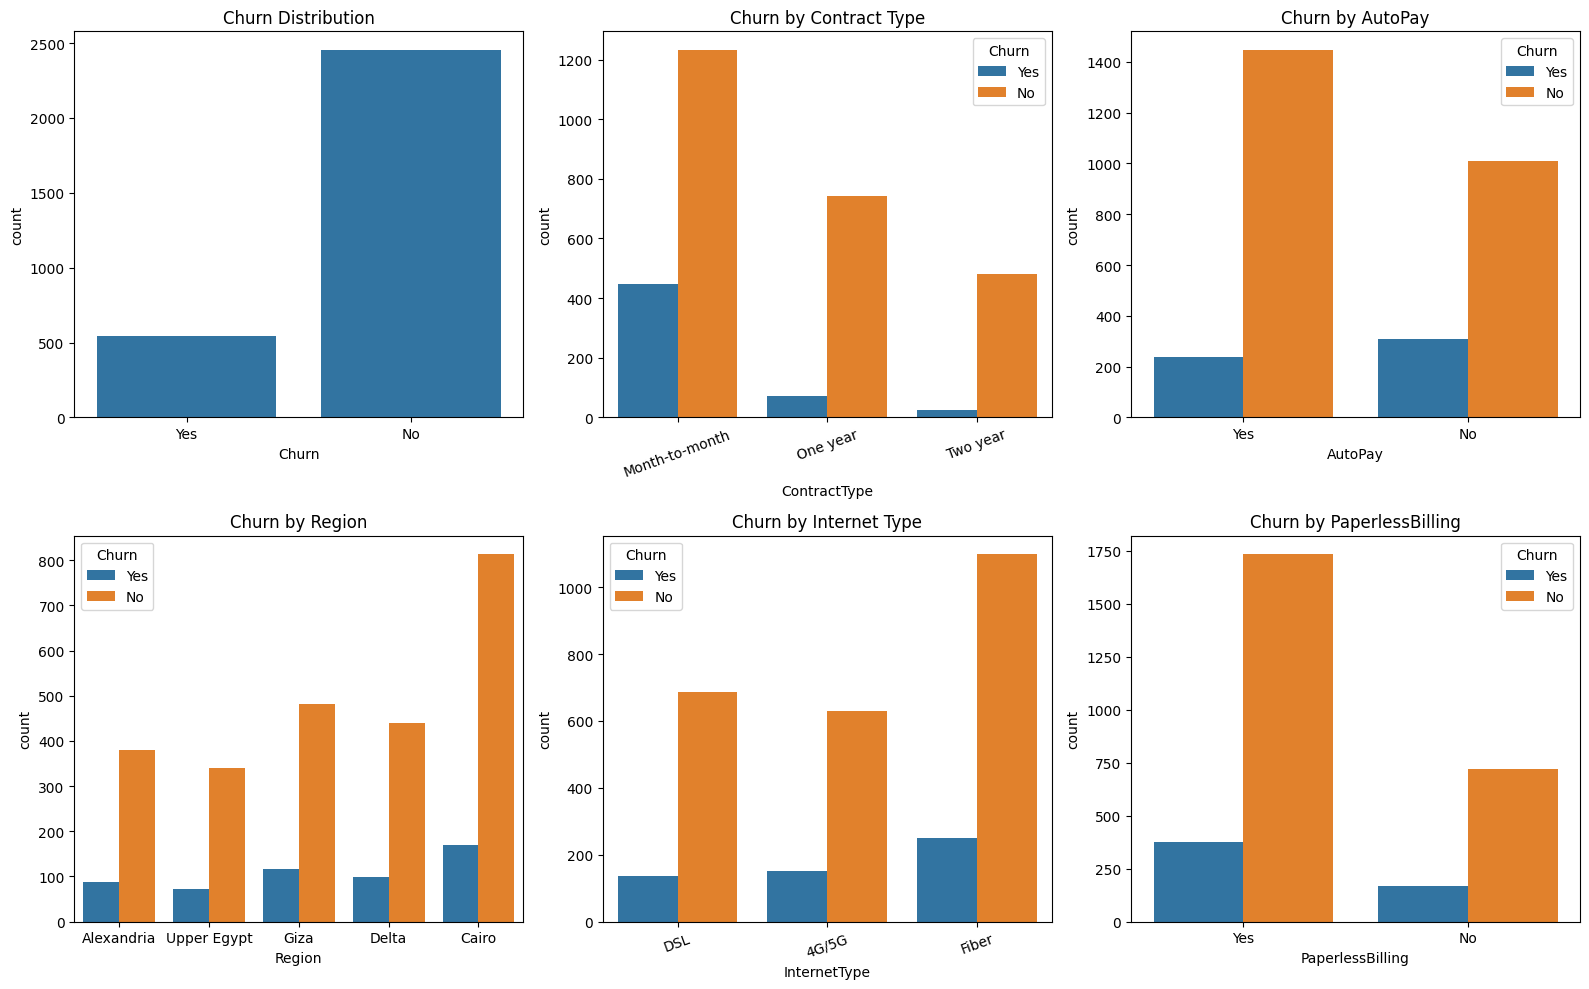

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.countplot(data=df, x="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Churn Distribution")

sns.countplot(data=df, x="ContractType", hue="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Churn by Contract Type")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="AutoPay", hue="Churn", ax=axes[0, 2])
axes[0, 2].set_title("Churn by AutoPay")

sns.countplot(data=df, x="Region", hue="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Churn by Region")

sns.countplot(data=df, x="InternetType", hue="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn by Internet Type")
axes[1, 1].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="PaperlessBilling", hue="Churn", ax=axes[1, 2])
axes[1, 2].set_title("Churn by PaperlessBilling")

plt.tight_layout()
plt.show()

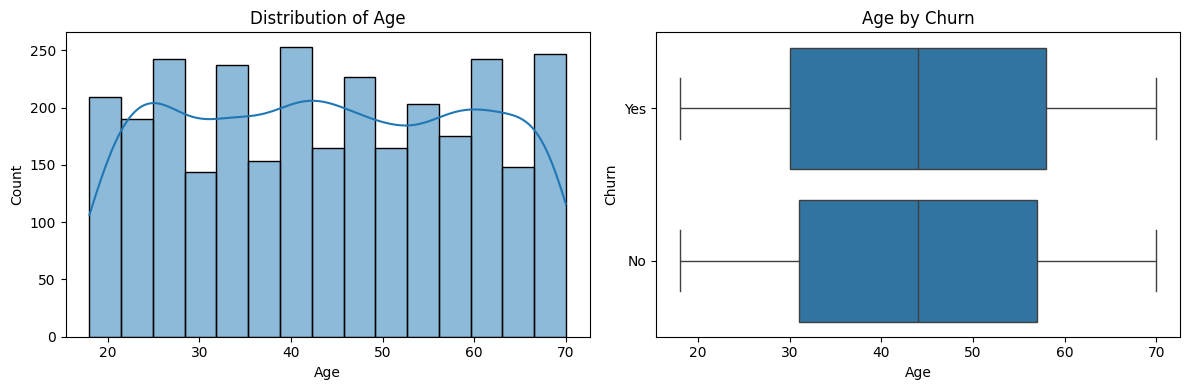

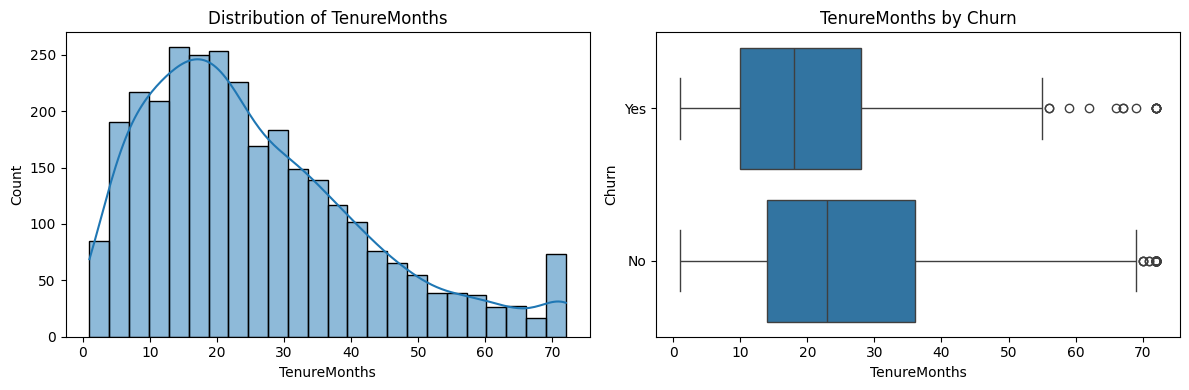

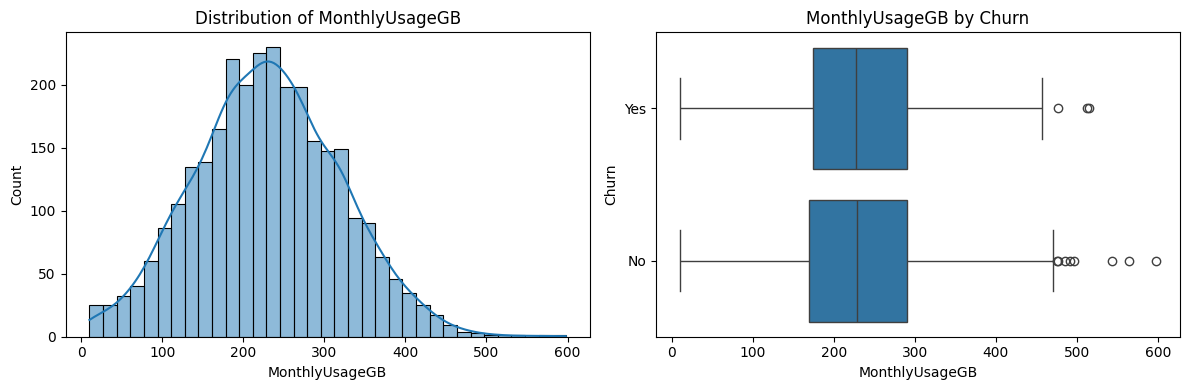

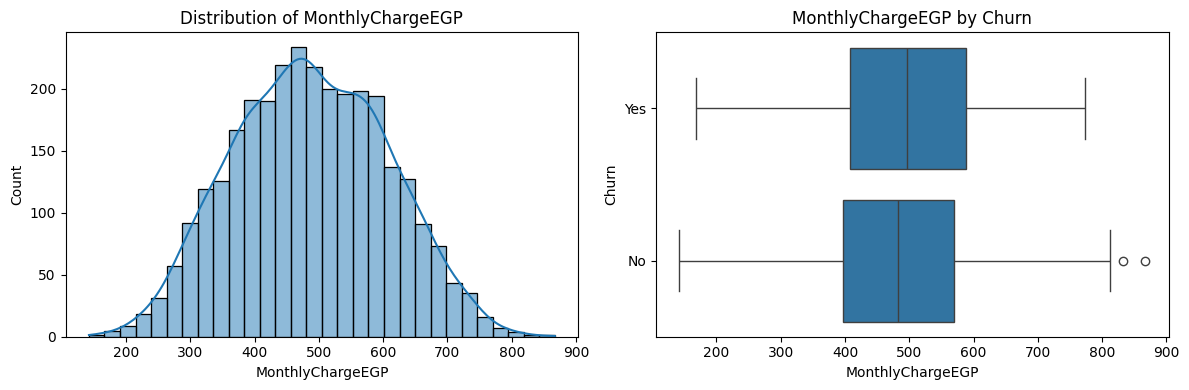

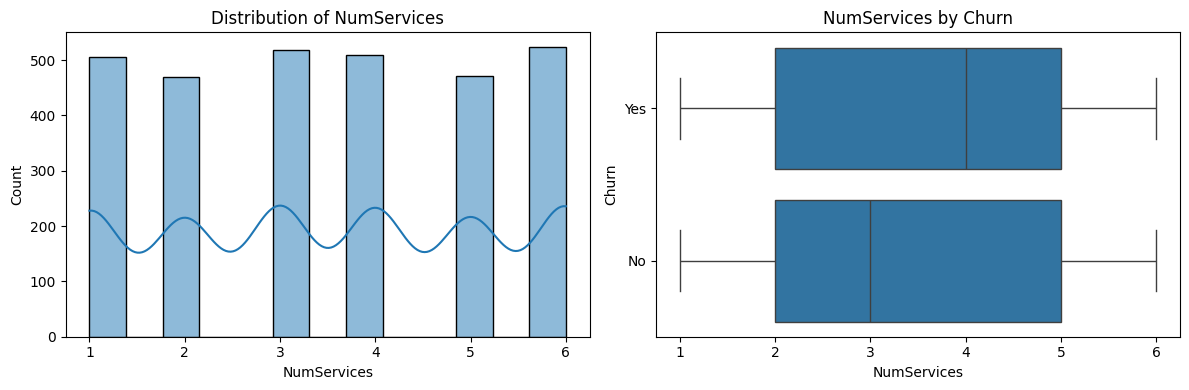

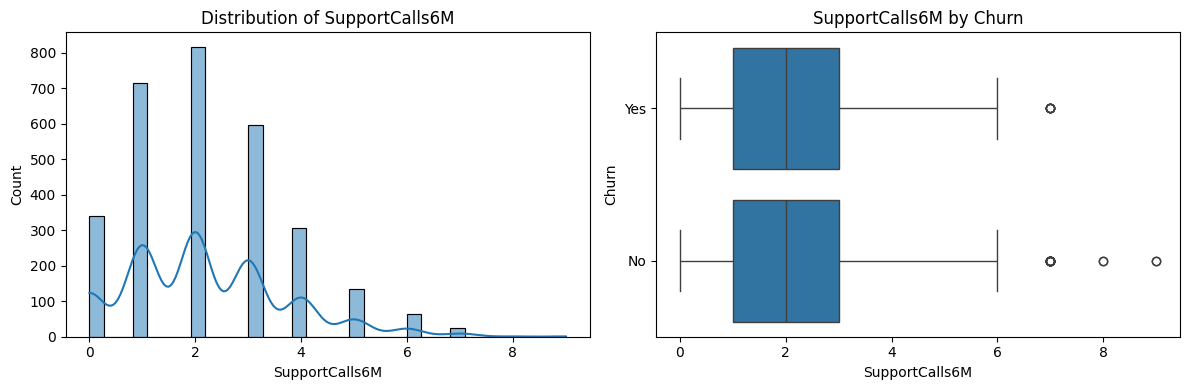

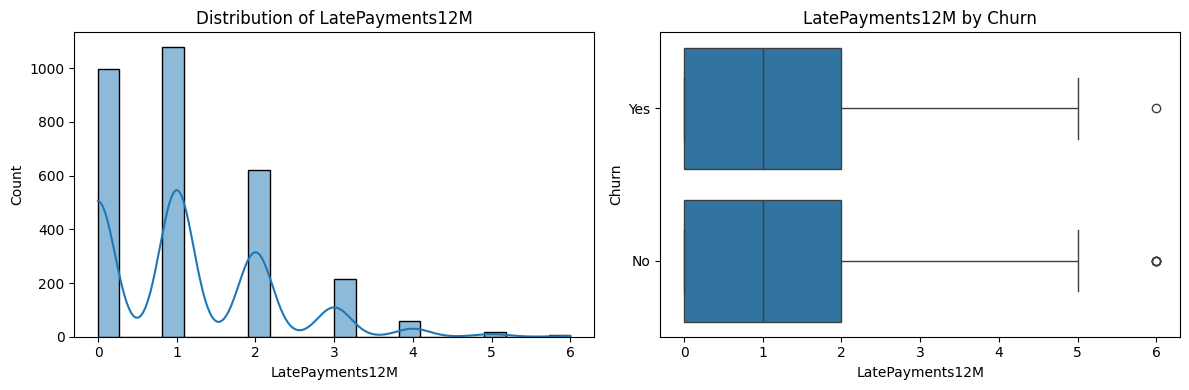

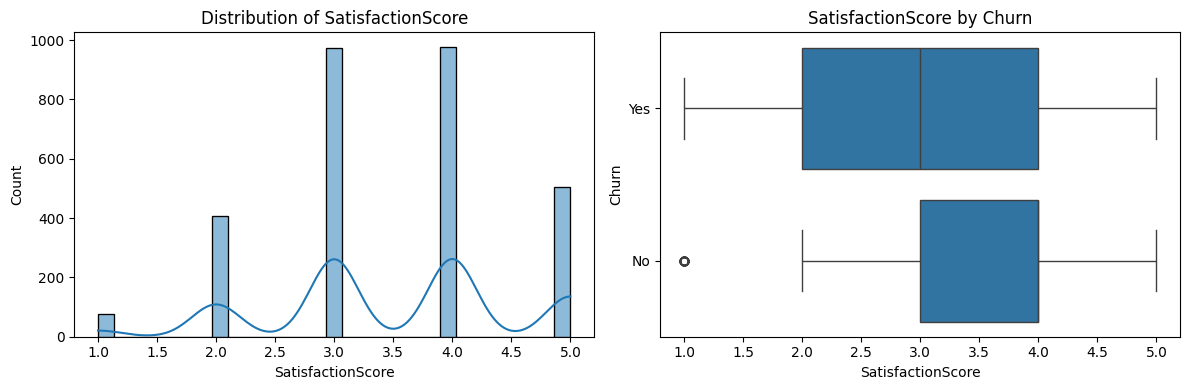

In [14]:
numerical_features_eda = df.select_dtypes(include="number").columns.tolist()
numerical_features_eda.remove("Future12MRevenueEGP")

for col in numerical_features_eda:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(data=df, x=col, y="Churn", orient="h", ax=axes[1])
    axes[1].set_title(f"{col} by Churn")

    plt.tight_layout()
    plt.show()

### EDA Summary — at least five observations

1. The dataset contains **3,000 customers and 16 columns**.
2. `CustomerID` is unique for every customer, confirming that it is an identifier rather than a predictive business feature.
3. Missing values are present in `InternetType`, `MonthlyUsageGB`, and `SatisfactionScore`; these will be handled inside the preprocessing pipeline.
4. Churn is not evenly distributed, so accuracy alone can hide poor performance on the minority churn class.
5. `ContractType` and `AutoPay` show visibly different churn patterns; the rate tables above are used to compare the groups rather than relying only on counts.
6. The numerical variables have different scales, which is important for distance- and margin-based algorithms such as KNN and SVM.

### Business Questions

**1. Which column must be excluded because it is an identifier?**  
`CustomerID` must be excluded because it identifies a customer but does not represent a meaningful customer behavior or attribute.

**2. Why should `Future12MRevenueEGP` not be used to predict current churn?**  
It represents a future outcome. Using it as an input would give the churn model information that would not be available at prediction time and would create target leakage.

**3. Is accuracy sufficient for churn prediction?**  
No. Churn is a classification problem where the minority class can be missed even when overall accuracy looks high. Precision, recall, F1, and ROC-AUC should also be considered.

**4. Which algorithms are sensitive to feature scaling?**  
KNN and SVM are especially sensitive because they use distances or geometric margins. Logistic regression and regularized linear models also benefit from standardized features. Tree-based models are generally much less sensitive to scaling.